In [1]:
import os
import re
import glob
import pandas as pd
from IPython.display import display, Markdown
from collections import OrderedDict
import pylhe
from scipy.interpolate import griddata
from scipy.interpolate import interp1d
import pyslha
import xml.etree.ElementTree as ET
import pyslha
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

defaultPars = {'figure.figsize': (5, 4), 'lines.markersize' : 4, 'axes.titlesize' : 13, 'font.size' : 13,
               'axes.labelsize' : 16, 'xtick.labelsize' : 13, 'ytick.labelsize' : 13, 'legend.fontsize' : 10,
               "text.usetex": True, "font.family": "sans-serif", "font.sans-serif": ["Helvetica"],
               'font.family':'Times New Roman', 'font.serif':'Times New Roman', "savefig.dpi" : 300,
               'contour.linewidth' : 2.0, 'lines.linewidth' : 2.0, 'axes.grid' : True,
               'grid.linewidth' : 0.5, 'grid.color' : 'lightgray', 'axes.axisbelow' : True
               }
plt.rcParams.update(defaultPars) #Figure resolution
pd.set_option('display.max_rows', 200)

cm = plt.colormaps['RdYlBu']


In [2]:
pd.read_pickle('../ma5Results_axial_all.pcl')

,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV),Efficiency,Efficiency_Err
0,IM0,8.534284,8.538081,0.000260,dma_1000_10,10.0,1000.0,0.096790,0.001117
1,IM1,4.409492,4.414570,0.000260,dma_1000_10,10.0,1000.0,0.074766,0.000982
2,IM2,3.336647,3.345726,0.000260,dma_1000_10,10.0,1000.0,0.056661,0.000855
3,IM3,2.449853,2.464980,0.000260,dma_1000_10,10.0,1000.0,0.043186,0.000746
4,IM4,2.141699,2.165333,0.000260,dma_1000_10,10.0,1000.0,0.032109,0.000643
...,...,...,...,...,...,...,...,...,...
2049,EM8,1.148875,1.224121,0.133546,dma_500_995,995.0,500.0,0.000786,0.000104
2050,EM9,1.150160,1.036460,0.133546,dma_500_995,995.0,500.0,0.000414,0.000075
2051,EM10,2.043404,3.589709,0.133546,dma_500_995,995.0,500.0,0.000193,0.000052
2052,EM11,2.679273,2.945245,0.133546,dma_500_995,995.0,500.0,0.000083,0.000034


In [3]:
pd.read_pickle('../ma5Results_axial_all_add.pcl')

,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV),Efficiency,Efficiency_Err
0,IM0,41.562392,41.576814,8.470793,dma_100_10,10.0,100.0,0.018590,0.000524
1,IM1,26.835339,26.859584,8.470793,dma_100_10,10.0,100.0,0.011417,0.000411
2,IM2,25.132638,25.183693,8.470793,dma_100_10,10.0,100.0,0.006729,0.000315
3,IM3,21.957866,22.056093,8.470793,dma_100_10,10.0,100.0,0.004156,0.000248
4,IM4,22.766144,22.943636,8.470793,dma_100_10,10.0,100.0,0.002485,0.000192
...,...,...,...,...,...,...,...,...,...
1711,EM8,0.789179,0.842512,0.009061,dma_600_750,750.0,600.0,0.001213,0.000129
1712,EM9,0.578438,0.521256,0.009061,dma_600_750,750.0,600.0,0.000818,0.000106
1713,EM10,1.118858,2.396994,0.009061,dma_600_750,750.0,600.0,0.000395,0.000073
1714,EM11,0.808475,0.889602,0.009061,dma_600_750,750.0,600.0,0.000286,0.000062


In [4]:
pd.read_pickle('../ma5Results_vector_all.pcl')

,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV),Efficiency,Efficiency_Err
0,IM0,8.669311,8.673169,0.001163,dmv_1000_10,10.0,1000.0,0.094259,0.001091
1,IM1,4.378603,4.383645,0.001163,dmv_1000_10,10.0,1000.0,0.073903,0.000966
2,IM2,3.262033,3.270897,0.001163,dmv_1000_10,10.0,1000.0,0.056563,0.000845
3,IM3,2.419868,2.434793,0.001163,dmv_1000_10,10.0,1000.0,0.042365,0.000731
4,IM4,2.009535,2.031696,0.001163,dmv_1000_10,10.0,1000.0,0.032610,0.000642
...,...,...,...,...,...,...,...,...,...
3401,EM8,1.077207,1.147759,0.037832,dmv_600_750,750.0,600.0,0.000848,0.000107
3402,EM9,0.843373,0.760001,0.037832,dmv_600_750,750.0,600.0,0.000539,0.000085
3403,EM10,1.082148,2.104174,0.037832,dmv_600_750,750.0,600.0,0.000364,0.000070
3404,EM11,1.262974,1.388347,0.037832,dmv_600_750,750.0,600.0,0.000188,0.000050


In [5]:
2054/26

79.0

In [6]:
df_a1 = pd.read_pickle('../ma5Results_axial_all.pcl')
df_a2 = pd.read_pickle('../ma5Results_axial_all_add.pcl')
df_a3 = pd.read_pickle('../ma5_axial_all_add/ma5Results_axial_all_fix.pcl')
dfs_a = [df_a1, df_a2, df_a3]

df_a = pd.concat(dfs_a, ignore_index=True)

df_v1 = pd.read_pickle('../ma5Results_vector_all.pcl')
df_v2 = pd.read_pickle('../ma5_vector_all_add/ma5Results_vector_all_fix.pcl')
dfs_v = [df_v1, df_v2]
df_v = pd.concat(dfs_v, ignore_index=True)

In [7]:
df_v = df_v[~(df_v['mMed (GeV)']==300.)]

In [8]:
df_v

,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV),Efficiency,Efficiency_Err
0,IM0,8.669311,8.673169,0.001163,dmv_1000_10,10.0,1000.0,0.094259,0.001091
1,IM1,4.378603,4.383645,0.001163,dmv_1000_10,10.0,1000.0,0.073903,0.000966
2,IM2,3.262033,3.270897,0.001163,dmv_1000_10,10.0,1000.0,0.056563,0.000845
3,IM3,2.419868,2.434793,0.001163,dmv_1000_10,10.0,1000.0,0.042365,0.000731
4,IM4,2.009535,2.031696,0.001163,dmv_1000_10,10.0,1000.0,0.032610,0.000642
...,...,...,...,...,...,...,...,...,...
3531,EM8,2.744042,2.923763,30.219120,dmv_1_750,750.0,1.0,0.000324,0.000068
3532,EM9,2.106118,1.897917,30.219120,dmv_1_750,750.0,1.0,0.000211,0.000055
3533,EM10,2.806340,4.708786,30.219120,dmv_1_750,750.0,1.0,0.000141,0.000045
3534,EM11,3.153960,3.467054,30.219120,dmv_1_750,750.0,1.0,0.000070,0.000031


In [9]:
df_a

,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV),Efficiency,Efficiency_Err
0,IM0,8.534284,8.538081,0.00026,dma_1000_10,10.0,1000.0,0.096790,0.001117
1,IM1,4.409492,4.414570,0.00026,dma_1000_10,10.0,1000.0,0.074766,0.000982
2,IM2,3.336647,3.345726,0.00026,dma_1000_10,10.0,1000.0,0.056661,0.000855
3,IM3,2.449853,2.464980,0.00026,dma_1000_10,10.0,1000.0,0.043186,0.000746
4,IM4,2.141699,2.165333,0.00026,dma_1000_10,10.0,1000.0,0.032109,0.000643
...,...,...,...,...,...,...,...,...,...
3895,EM8,3.022929,3.220916,31.29521,dma_1_750,750.0,1.0,0.000308,0.000066
3896,EM9,3.530696,3.181667,31.29521,dma_1_750,750.0,1.0,0.000126,0.000042
3897,EM10,4.704548,7.893804,31.29521,dma_1_750,750.0,1.0,0.000084,0.000034
3898,EM11,5.287295,5.812167,31.29521,dma_1_750,750.0,1.0,0.000042,0.000024


In [10]:
# get datapoints in common
mCols = ['mMed (GeV)', 'mchi (GeV)']
keys = list(df_v[mCols].columns.values)
i1 = df_v.set_index(keys).index
i2 = df_a.set_index(keys).index
dataVec = df_v[i1.isin(i2)]
dataAx = df_a[i2.isin(i1)]
print(len(dataAx), len(dataVec))

3510 3510


In [11]:
# choose only EM
srs = [c for c in dataAx['Signal Region'] if not 'IM' in c]
dataAx = dataAx[dataAx['Signal Region'].isin(srs)]
dataVec = dataVec[dataVec['Signal Region'].isin(srs)]

In [12]:
dataVec.T

,13,14,15,16,17,18,19,20,21,22,...,3526,3527,3528,3529,3530,3531,3532,3533,3534,3535
Signal Region,EM0,EM1,EM2,EM3,EM4,EM5,EM6,EM7,EM8,EM9,...,EM3,EM4,EM5,EM6,EM7,EM8,EM9,EM10,EM11,EM12
Sigma_95_exp (pb),21.371544,7.056581,3.498511,3.173329,2.192671,1.043132,0.870158,0.810785,0.572944,0.51147,...,6.40832,6.183215,3.930554,3.565803,3.463405,2.744042,2.106118,2.80634,3.15396,5.408227
Sigma_95_obs (pb),21.377747,7.054959,3.497781,3.204326,2.243252,1.075557,0.941311,0.946172,0.614823,0.460852,...,6.458812,6.28056,4.029213,3.778094,3.866176,2.923763,1.897917,4.708786,3.467054,4.616471
Sigma_theoretical (pb),0.001163,0.001163,0.001163,0.001163,0.001163,0.001163,0.001163,0.001163,0.001163,0.001163,...,30.21912,30.21912,30.21912,30.21912,30.21912,30.21912,30.21912,30.21912,30.21912,30.21912
SAF File,dmv_1000_10,dmv_1000_10,dmv_1000_10,dmv_1000_10,dmv_1000_10,dmv_1000_10,dmv_1000_10,dmv_1000_10,dmv_1000_10,dmv_1000_10,...,dmv_1_750,dmv_1_750,dmv_1_750,dmv_1_750,dmv_1_750,dmv_1_750,dmv_1_750,dmv_1_750,dmv_1_750,dmv_1_750
mMed (GeV),10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,...,750.0,750.0,750.0,750.0,750.0,750.0,750.0,750.0,750.0,750.0
mchi (GeV),1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Efficiency,0.020356,0.01734,0.014198,0.009755,0.012973,0.007723,0.004922,0.002587,0.001716,0.000984,...,0.004604,0.004224,0.001971,0.001126,0.000563,0.000324,0.000211,0.000141,0.00007,0.000042
Efficiency_Err,0.000507,0.000468,0.000423,0.000351,0.000405,0.000312,0.000249,0.000181,0.000147,0.000111,...,0.000255,0.000244,0.000167,0.000126,0.000089,0.000068,0.000055,0.000045,0.000031,0.000024


In [13]:
dataAx = dataAx.rename(columns={'Efficiency': 'eff_a', 'Efficiency_Err': 'stat_a'})
dataVec = dataVec.rename(columns={'Efficiency': 'eff_v', 'Efficiency_Err': 'stat_v'})

In [14]:
dataVec

,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV),eff_v,stat_v
13,EM0,21.371544,21.377747,0.001163,dmv_1000_10,10.0,1000.0,0.020356,0.000507
14,EM1,7.056581,7.054959,0.001163,dmv_1000_10,10.0,1000.0,0.017340,0.000468
15,EM2,3.498511,3.497781,0.001163,dmv_1000_10,10.0,1000.0,0.014198,0.000423
16,EM3,3.173329,3.204326,0.001163,dmv_1000_10,10.0,1000.0,0.009755,0.000351
17,EM4,2.192671,2.243252,0.001163,dmv_1000_10,10.0,1000.0,0.012973,0.000405
...,...,...,...,...,...,...,...,...,...
3531,EM8,2.744042,2.923763,30.219120,dmv_1_750,750.0,1.0,0.000324,0.000068
3532,EM9,2.106118,1.897917,30.219120,dmv_1_750,750.0,1.0,0.000211,0.000055
3533,EM10,2.806340,4.708786,30.219120,dmv_1_750,750.0,1.0,0.000141,0.000045
3534,EM11,3.153960,3.467054,30.219120,dmv_1_750,750.0,1.0,0.000070,0.000031


In [15]:
file_names = list(dataAx['SAF File'].unique())

In [16]:
reducedChis = []
redChis_dict = {}

for f in file_names:
    eff_a = np.array(dataAx[dataAx['SAF File'] == f]['eff_a'])
    stat_a = np.array(dataAx[dataAx['SAF File'] == f]['stat_a'])
    
    f_v = f.replace('a', 'v')
    eff_v = np.array(dataVec[dataVec['SAF File'] == f_v]['eff_v'])
    stat_v = np.array(dataVec[dataVec['SAF File'] == f_v]['stat_v'])

    errSysMult = 0.10
    err_a = np.sqrt(stat_a**2 + (errSysMult*eff_a)**2)
    err_v = np.sqrt(stat_v**2 + (errSysMult*eff_v)**2)

    diff = (eff_v - eff_a)**2
    sigmaTot = (err_a**2 + err_v**2)
    redChiList = []

    for i, d in enumerate(diff):
        
        if sigmaTot[i] == 0:
            continue
        else:
            redChiList.append(diff[i]/sigmaTot[i])

    redChi = np.array(redChiList)
    dof = len(diff) - 1

    np.nan_to_num(redChi, posinf=0)
    reducedChis.append(redChi.sum()/dof)
    redChis_dict[f] = redChi.sum()/dof


In [17]:
dataVec[(dataVec['mMed (GeV)'] == 250)&(dataVec['mchi (GeV)'] == 100)]

,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV),eff_v,stat_v
533,EM0,103.493537,103.519601,1293.069,dmv_100_250,250.0,100.0,0.004156,0.000241
534,EM1,43.844171,43.834092,1293.069,dmv_100_250,250.0,100.0,0.002813,0.000198
535,EM2,41.968762,41.960011,1293.069,dmv_100_250,250.0,100.0,0.001176,0.000128
536,EM3,43.075181,43.414604,1293.069,dmv_100_250,250.0,100.0,0.000686,0.000098
537,EM4,41.519722,42.173378,1293.069,dmv_100_250,250.0,100.0,0.000630,0.000094
538,EM5,39.307166,40.293799,1293.069,dmv_100_250,250.0,100.0,0.000210,0.000054
539,EM6,71.832094,76.108654,1293.069,dmv_100_250,250.0,100.0,0.000056,0.000028
540,EM7,27.907716,31.153172,1293.069,dmv_100_250,250.0,100.0,0.000070,0.000031
541,EM8,63.569642,67.733139,1293.069,dmv_100_250,250.0,100.0,0.000014,0.000014
542,EM9,-1.000000,-1.000000,1293.069,dmv_100_250,250.0,100.0,0.000000,0.000000


In [18]:
dataAx[(dataAx['mchi (GeV)'] == 100)&(dataAx['mMed (GeV)'] < 500)]

,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV),eff_a,stat_a
2067,EM0,59.878589,59.893670,8.470793,dma_100_10,10.0,100.0,0.007173,0.000326
2068,EM1,26.252263,26.246228,8.470793,dma_100_10,10.0,100.0,0.004688,0.000263
2069,EM2,19.278412,19.274392,8.470793,dma_100_10,10.0,100.0,0.002573,0.000195
2070,EM3,17.828594,17.969070,8.470793,dma_100_10,10.0,100.0,0.001671,0.000157
2071,EM4,19.423944,19.729741,8.470793,dma_100_10,10.0,100.0,0.001346,0.000141
2072,EM5,10.208019,10.464246,8.470793,dma_100_10,10.0,100.0,0.000754,0.000106
2073,EM6,20.909670,22.154538,8.470793,dma_100_10,10.0,100.0,0.000192,0.000053
2074,EM7,22.001639,24.560259,8.470793,dma_100_10,10.0,100.0,0.000089,0.000036
2075,EM8,12.027955,12.815728,8.470793,dma_100_10,10.0,100.0,0.000074,0.000033
2076,EM9,30.103512,27.127616,8.470793,dma_100_10,10.0,100.0,0.000030,0.000021


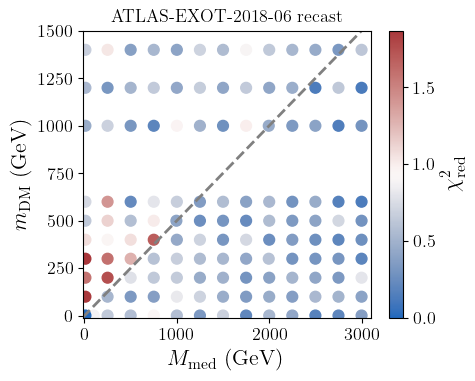

In [21]:
mmed = []
mdm = []
redChi = []

for f, rchi in redChis_dict.items():
    dm = int(f.split('_')[1])
    med = int(f.split('_')[2])

    mmed.append(med)
    mdm.append(dm)
    redChi.append(rchi)


plt.scatter(x=mmed, y=mdm, c=redChi,
            cmap=plt.colormaps.get_cmap('vlag'), s=60)

plt.axline((1, 1), slope=1/2, linestyle='--', color='gray')

cbar=plt.colorbar(label=r'$\chi^{2}_{\rm red}$')
plt.xlabel(r'$M_{\rm med}$ (GeV)')
plt.xlim(-20,3100)
plt.ylabel(r'$m_{\rm DM}$ (GeV)')
plt.ylim(-10,1500)
plt.title('ATLAS-EXOT-2018-06 recast')
plt.grid()

plt.tight_layout()
plt.savefig('./figures/comp-effs-spin1.png')

plt.show()

In [21]:
from scipy.stats import chi2

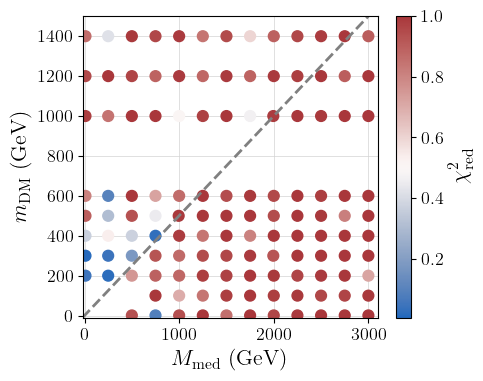

In [25]:
mmed = []
mdm = []
redChi = []
pval = []

for f, rchi in redChis_dict.items():
    dm = int(f.split('_')[1])
    med = int(f.split('_')[2])

    mmed.append(med)
    mdm.append(dm)
    redChi.append(rchi)
    p = 1 - chi2.cdf(rchi*21, df=21)
    pval.append(p)


plt.scatter(x=mmed, y=mdm, c=pval, vmin=0.005, vmax=1.,
            cmap=plt.colormaps.get_cmap('vlag'), s=60)

plt.axline((1, 1), slope=1/2, linestyle='--', color='gray')

cbar=plt.colorbar(label=r'$\chi^{2}_{\rm red}$')
plt.xlabel(r'$M_{\rm med}$ (GeV)')
plt.xlim(-20,3100)
plt.ylabel(r'$m_{\rm DM}$ (GeV)')
plt.ylim(-10,1500)

plt.tight_layout()
# plt.savefig('./figures/comp-effs-spin1.png')

plt.show()

In [26]:
min(pval)

np.float64(0.00916330065981108)

In [27]:
mtuple = []
for i, m in enumerate(mmed):
    mtuple.append((mdm[i], m))

In [28]:
mtuple.sort()

In [29]:
for pair in mtuple:
    print(pair, end=', ')

(1, 100), (1, 250), (1, 500), (1, 750), (1, 1000), (1, 1250), (1, 1500), (1, 1750), (1, 2000), (1, 2250), (1, 2500), (1, 2750), (1, 3000), (100, 10), (100, 250), (100, 300), (100, 500), (100, 750), (100, 1000), (100, 1250), (100, 1500), (100, 1750), (100, 2000), (100, 2250), (100, 2500), (100, 2750), (100, 3000), (200, 10), (200, 250), (200, 500), (200, 750), (200, 1000), (200, 1250), (200, 1500), (200, 1750), (200, 2000), (200, 2250), (200, 2500), (200, 2750), (200, 3000), (300, 10), (300, 250), (300, 500), (300, 750), (300, 1000), (300, 1250), (300, 1500), (300, 1750), (300, 1995), (300, 2250), (300, 2500), (300, 2750), (300, 3000), (400, 10), (400, 250), (400, 500), (400, 750), (400, 1000), (400, 1250), (400, 1500), (400, 1750), (400, 2000), (400, 2250), (400, 2500), (400, 2750), (400, 3000), (500, 10), (500, 250), (500, 500), (500, 750), (500, 995), (500, 1250), (500, 1500), (500, 1750), (500, 2000), (500, 2250), (500, 2500), (500, 2750), (500, 3000), (600, 10), (600, 250), (600, 5

In [22]:
len(mtuple)

131

In [23]:
# merge dfs
dataComb = pd.merge(dataAx, dataVec, on=['mchi (GeV)', 'mMed (GeV)', 'Signal Region'], how='inner')

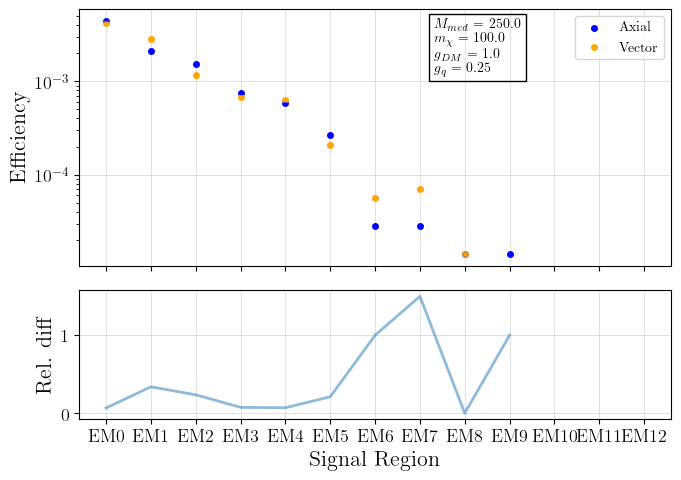

In [27]:
# plot eff diff
mxd = 100.
mmed = 250.
mFilter = (dataComb['mchi (GeV)'] == mxd) & (dataComb['mMed (GeV)'] == mmed)
x = dataComb[mFilter]['Signal Region']
y1 = dataComb[mFilter]['eff_a']
y1_err = dataComb[mFilter]['stat_a']
y2 = dataComb[mFilter]['eff_v']
y2_err = dataComb[mFilter]['stat_v']

params = {'$M_{med}$' : mmed, '$m_{\chi}$': mxd, '$g_{DM}$': 1., '$g_{q}$': 0.25}
textstr = '\n'.join([r'%s = %s' %(k,v) for k,v in params.items()])

fig, ax = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios':[2,1]}, figsize=(7,5))

ax[0].scatter(x, y1, label='Axial', color='blue')
ax[0].errorbar(x, y1, yerr=y1_err, marker='.', linewidth=0.0, color='blue')
ax[0].scatter(x, y2, label='Vector', color='orange')
ax[0].errorbar(x, y2, yerr=y2_err, marker='.', linewidth=0.0, color='orange')

ax[0].set_yscale('log')

diff = np.abs(y1 - y2)
relDiff = diff/y1
diffError = diff/np.sqrt(y1_err**2 + y2_err**2)

ax[1].plot(x, relDiff, alpha=.5, label='rel diff')
# ax[1].plot(x, diffError, alpha=.5, label=r'$\Delta \epsilon / \sigma_{\epsilon}$')

ax[0].text(.6, 2.7, textstr, bbox=dict(facecolor='none', edgecolor='black'), transform=plt.gca().transAxes, fontsize=10)


ax[1].set_xlabel('Signal Region')
ax[0].set_ylabel('Efficiency')
ax[0].legend()
ax[1].set_ylabel('Rel. diff')
plt.tight_layout()

# plt.savefig('./figures/comp_eff_spin1.png')

plt.show()

In [28]:
y1

936    0.004454
937    0.002101
938    0.001541
939    0.000742
940    0.000588
941    0.000266
942    0.000028
943    0.000028
944    0.000014
945    0.000014
946    0.000000
947    0.000000
948    0.000000
Name: eff_a, dtype: float64

In [29]:
y1_err

936    1.112232e-06
937    3.603228e-07
938    2.262788e-07
939    7.567781e-08
940    5.338617e-08
941    1.624371e-08
942    5.547531e-10
943    5.547531e-10
944    1.961349e-10
945    1.961349e-10
946    0.000000e+00
947    0.000000e+00
948    0.000000e+00
Name: stat_a, dtype: float64

In [100]:
dataVec_new = pd.read_pickle('../ma5_test_vector_match/ma5Results_test_vector_match.pcl')
dataAx_new = pd.read_pickle('../ma5_test_axial_match/ma5Results_test_axial_match.pcl')

In [101]:
# choose only EM
srs = [c for c in dataAx_new['Signal Region'] if not 'IM' in c]
dataAx_new = dataAx_new[dataAx_new['Signal Region'].isin(srs)]
dataVec_new = dataVec_new[dataVec_new['Signal Region'].isin(srs)]

In [102]:
dataAx_new

,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV),Efficiency,Efficiency_Err
13,EM0,92.583641,92.606957,276.0927,dma_100_250,250.0,100.0,0.004637,1.075050e-04
14,EM1,46.987566,46.976765,276.0927,dma_100_250,250.0,100.0,0.002614,8.376366e-05
15,EM2,32.750442,32.743613,276.0927,dma_100_250,250.0,100.0,0.001511,7.091360e-05
16,EM3,39.267812,39.577214,276.0927,dma_100_250,250.0,100.0,0.000752,2.242561e-05
17,EM4,38.267204,38.869657,276.0927,dma_100_250,250.0,100.0,0.000685,3.217050e-05
18,EM5,33.391418,34.229562,276.0927,dma_100_250,250.0,100.0,0.000231,8.148441e-06
19,EM6,45.831637,48.560246,276.0927,dma_100_250,250.0,100.0,0.000088,7.951834e-06
20,EM7,62.045541,69.260956,276.0927,dma_100_250,250.0,100.0,0.000032,2.153017e-06
21,EM8,57.350123,61.106272,276.0927,dma_100_250,250.0,100.0,0.000016,1.291206e-06
22,EM9,60.781024,54.772489,276.0927,dma_100_250,250.0,100.0,0.000007,9.786407e-07


In [103]:
dataVec_new

,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV),Efficiency,Efficiency_Err
13,EM0,91.969957,91.993122,640.3959,dmv_100_250,250.0,100.0,0.004669,1.066803e-04
14,EM1,45.125985,45.114188,640.3959,dmv_100_250,250.0,100.0,0.002720,8.103377e-05
15,EM2,38.095991,38.088048,640.3959,dmv_100_250,250.0,100.0,0.001296,4.385584e-05
16,EM3,38.417130,38.719829,640.3959,dmv_100_250,250.0,100.0,0.000769,3.516686e-05
17,EM4,38.689571,39.298673,640.3959,dmv_100_250,250.0,100.0,0.000677,3.252566e-05
18,EM5,37.073061,38.003616,640.3959,dmv_100_250,250.0,100.0,0.000208,7.665222e-06
19,EM6,41.243114,43.698531,640.3959,dmv_100_250,250.0,100.0,0.000098,1.100990e-05
20,EM7,33.094652,36.943303,640.3959,dmv_100_250,250.0,100.0,0.000059,2.126702e-05
21,EM8,47.141221,50.228738,640.3959,dmv_100_250,250.0,100.0,0.000019,3.679570e-06
22,EM9,63.947607,57.626047,640.3959,dmv_100_250,250.0,100.0,0.000007,7.500524e-07


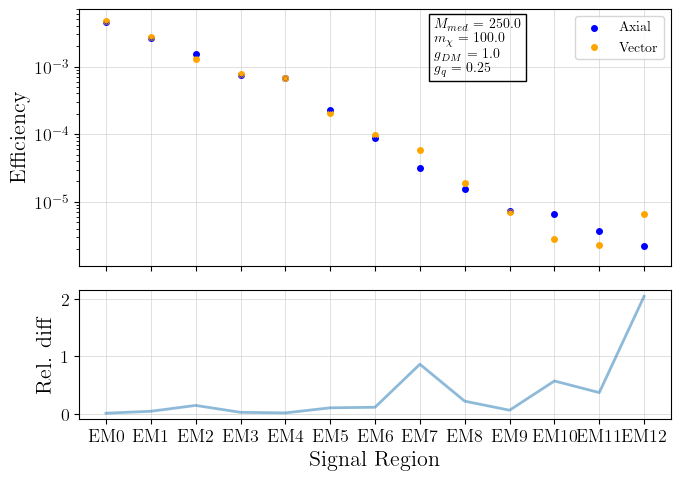

In [104]:
mmed = dataAx_new['mMed (GeV)'].tolist()[0]
mxd = dataAx_new['mchi (GeV)'].tolist()[0]

params = {'$M_{med}$' : mmed, '$m_{\chi}$': mxd, '$g_{DM}$': 1., '$g_{q}$': 0.25}
textstr = '\n'.join([r'%s = %s' %(k,v) for k,v in params.items()])

fig, ax = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios':[2,1]}, figsize=(7,5))

x = dataAx_new['Signal Region']
y1 = np.array(dataAx_new['Efficiency'])
y2 = np.array(dataVec_new['Efficiency'])
y1_err = np.array(dataAx_new['Efficiency_Err'])
y2_err = np.array(dataVec_new['Efficiency_Err'])

ax[0].scatter(x, y1, label='Axial', color='blue')
ax[0].errorbar(x, y1, yerr=y1_err, marker='.', linewidth=0.0, color='blue')
ax[0].scatter(x, y2, label='Vector', color='orange')
ax[0].errorbar(x, y2, yerr=y2_err, marker='.', linewidth=0.0, color='orange')

ax[0].set_yscale('log')

diff = np.abs(y1 - y2)
relDiff = diff/y1
diffError = diff/np.sqrt(y1_err**2 + y2_err**2)

ax[1].plot(x, relDiff, alpha=.5, label='rel diff')
# ax[1].plot(x, diffError, alpha=.5, label=r'$\Delta \epsilon / \sigma_{\epsilon}$')

ax[0].text(.6, 2.7, textstr, bbox=dict(facecolor='none', edgecolor='black'), transform=plt.gca().transAxes, fontsize=10)


ax[1].set_xlabel('Signal Region')
ax[0].set_ylabel('Efficiency')
ax[0].legend()
ax[1].set_ylabel('Rel. diff')
plt.tight_layout()

# plt.savefig('./figures/comp_eff_spin1.png')

plt.show()

In [107]:
(y1 - y2)**2

array([9.72086811e-10, 1.12237410e-08, 4.63971677e-08, 2.73951844e-10,
       7.03687103e-11, 5.42477806e-10, 9.47055833e-11, 7.44422703e-10,
       1.12681386e-11, 1.90167368e-13, 1.36867162e-11, 1.77646933e-12,
       2.01146142e-11])

In [106]:
(y1_err**2 + y2_err**2)

array([2.29380082e-08, 1.35828224e-08, 6.95207376e-09, 1.73961626e-09,
       2.09285995e-09, 1.25152728e-10, 1.84449538e-10, 4.56921746e-10,
       1.52064502e-11, 1.52031616e-12, 2.95945077e-12, 3.80287910e-12,
       1.83385355e-11])

In [109]:
np.array((y1 - y2)**2 / (y1_err**2 + y2_err**2)).sum()/(dof)

np.float64(1.7721399190168754)

In [84]:
dataScalar_new = pd.read_pickle('../ma5_test_spin0_scalar_match/ma5Results_test_scalar_match.pcl')
dataPseudo_new = pd.read_pickle('../ma5_test_spin0_pseudo_match/ma5Results_test_pseudo_match.pcl')

In [85]:
# choose only EM
srs = [c for c in dataScalar_new['Signal Region'] if not 'IM' in c]
dataScalar_new = dataScalar_new[dataScalar_new['Signal Region'].isin(srs)]
dataPseudo_new = dataPseudo_new[dataPseudo_new['Signal Region'].isin(srs)]

In [86]:
dataScalar_new

,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV),Efficiency,Efficiency_Err
13,EM0,28.991585,28.998887,1.301264,dms_1_350,1,1.0,0.014791,5.031022e-04
14,EM1,12.852657,12.849702,1.301264,dms_1_350,1,1.0,0.009550,2.620176e-04
15,EM2,8.364061,8.362317,1.301264,dms_1_350,1,1.0,0.005901,2.334939e-04
16,EM3,9.662193,9.738324,1.301264,dms_1_350,1,1.0,0.003058,9.309664e-05
17,EM4,9.276808,9.422926,1.301264,dms_1_350,1,1.0,0.002820,1.033406e-04
18,EM5,9.162013,9.391982,1.301264,dms_1_350,1,1.0,0.000841,2.131130e-05
19,EM6,13.164819,13.948593,1.301264,dms_1_350,1,1.0,0.000306,9.839137e-06
20,EM7,15.101814,16.858038,1.301264,dms_1_350,1,1.0,0.000130,2.549294e-05
21,EM8,18.273888,19.470728,1.301264,dms_1_350,1,1.0,0.000049,2.893295e-06
22,EM9,24.233837,21.838192,1.301264,dms_1_350,1,1.0,0.000018,1.236870e-06


In [87]:
dataPseudo_new

,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV),Efficiency,Efficiency_Err
13,EM0,30.290153,30.297781,4.465051,dmp_1_350,1,1.0,0.014164,4.223470e-04
14,EM1,13.164313,13.161287,4.465051,dmp_1_350,1,1.0,0.009326,2.373667e-04
15,EM2,8.825366,8.823525,4.465051,dmp_1_350,1,1.0,0.005593,2.586481e-04
16,EM3,10.071019,10.150371,4.465051,dmp_1_350,1,1.0,0.002935,9.717783e-05
17,EM4,10.280444,10.442292,4.465051,dmp_1_350,1,1.0,0.002545,6.485633e-05
18,EM5,10.295219,10.553635,4.465051,dmp_1_350,1,1.0,0.000749,2.112310e-05
19,EM6,14.369305,15.224789,4.465051,dmp_1_350,1,1.0,0.000280,8.961815e-06
20,EM7,20.028271,22.357404,4.465051,dmp_1_350,1,1.0,0.000098,3.594650e-06
21,EM8,24.511813,26.117216,4.465051,dmp_1_350,1,1.0,0.000036,1.811863e-06
22,EM9,26.434241,23.821073,4.465051,dmp_1_350,1,1.0,0.000017,1.910783e-06


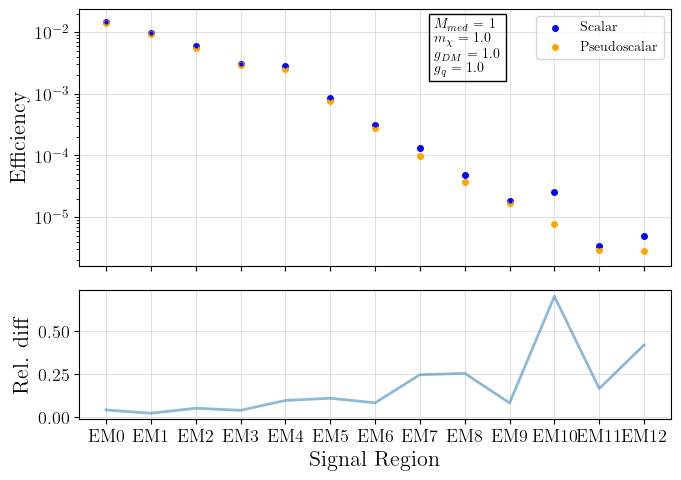

In [98]:
mmed = dataScalar_new['mMed (GeV)'].tolist()[0]
mxd = dataPseudo_new['mchi (GeV)'].tolist()[0]

params = {'$M_{med}$' : mmed, '$m_{\chi}$': mxd, '$g_{DM}$': 1., '$g_{q}$': 1.0}
textstr = '\n'.join([r'%s = %s' %(k,v) for k,v in params.items()])

fig, ax = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios':[2,1]}, figsize=(7,5))

x = dataScalar_new['Signal Region']
y1 = np.array(dataScalar_new['Efficiency'])
y2 = np.array(dataPseudo_new['Efficiency'])
y1_err = np.array(dataScalar_new['Efficiency_Err'])
y2_err = np.array(dataPseudo_new['Efficiency_Err'])

ax[0].scatter(x, y1, label='Scalar', color='blue')
ax[0].errorbar(x, y1, yerr=y1_err, marker='.', linewidth=0.0, color='blue')
ax[0].scatter(x, y2, label='Pseudoscalar', color='orange')
ax[0].errorbar(x, y2, yerr=y2_err, linewidth=0.0, color='orange')

ax[0].set_yscale('log')

diff = np.abs(y1 - y2)
relDiff = diff/y1
diffError = diff/np.sqrt(y1_err**2 + y2_err**2)

ax[1].plot(x, relDiff, alpha=.5, label='rel diff')
# ax[1].plot(x, diffError, alpha=.5, label=r'$\Delta \epsilon / \sigma_{\epsilon}$')

ax[0].text(.6, 2.7, textstr, bbox=dict(facecolor='none', edgecolor='black'), transform=plt.gca().transAxes, fontsize=10)


ax[1].set_xlabel('Signal Region')
ax[0].set_ylabel('Efficiency')
ax[0].legend()
ax[1].set_ylabel('Rel. diff')
plt.tight_layout()

# plt.savefig('./figures/comp_eff_spin1.png')

plt.show()

In [89]:
np.abs(y1 - y2)/y1

array([0.0423474 , 0.02345732, 0.05221255, 0.04027256, 0.09758176,
       0.11047332, 0.08365225, 0.24697157, 0.25529742, 0.0829276 ,
       0.70238931, 0.16662399, 0.42014838])

In [90]:
(y1_err**2 + y2_err**2)

array([4.31488789e-07, 1.24996158e-07, 1.21418283e-07, 1.81105135e-08,
       1.48856271e-08, 9.00356913e-10, 1.77122743e-10, 6.62811423e-10,
       1.16540068e-11, 5.18094095e-12, 2.21119526e-10, 2.98627304e-13,
       6.11700043e-13])

In [99]:
np.array((y1 - y2)**2 / (y1_err**2 + y2_err**2)).sum()/(dof+1)

np.float64(3.555391307927692)

In [95]:
y1

array([1.47905786e-02, 9.54995230e-03, 5.90079526e-03, 3.05836714e-03,
       2.81997949e-03, 8.41477461e-04, 3.05992977e-04, 1.29749334e-04,
       4.88370093e-05, 1.84089989e-05, 2.55283201e-05, 3.45012366e-06,
       4.92763704e-06])

In [96]:
y1_err

array([5.03102207e-04, 2.62017597e-04, 2.33493949e-04, 9.30966353e-05,
       1.03340620e-04, 2.13113021e-05, 9.83913727e-06, 2.54929385e-05,
       2.89329529e-06, 1.23687033e-06, 1.48545702e-05, 3.75098867e-07,
       7.40438194e-07])

In [77]:
3.096063e+03/2.093267e+05

0.014790578554957395

In [81]:
(np.sqrt(1.109077e+04) / 2.093267e+05) * 0.014790578554957395

np.float64(7.441172715443876e-06)

In [82]:
(3.096063e+03/2.093267e+05) * (np.sqrt(1.109077e+04))/ 3.096063e+03

np.float64(0.0005031022071107421)

In [83]:
np.sqrt(1.109077e+04) / 2.093267e+05

np.float64(0.0005031022071107421)

In [110]:
2.789887908142857*1e3*139

387794.4192318572

In [111]:
1.301264e+00*1e3*139

180875.696

In [25]:
pd.read_pickle('../ma5Results_scalar_all.pcl')

,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV),Efficiency,Efficiency_Err
0,IM0,-1.000000,-1.000000,2.062528e-07,dms_1000_1750,1,1000.0,0.211444,0.002289
1,IM1,-1.000000,-1.000000,2.062528e-07,dms_1000_1750,1,1000.0,0.177396,0.001992
2,IM2,-1.000000,-1.000000,2.062528e-07,dms_1000_1750,1,1000.0,0.140901,0.001661
3,IM3,-1.000000,-1.000000,2.062528e-07,dms_1000_1750,1,1000.0,0.109688,0.001336
4,IM4,-1.000000,-1.000000,2.062528e-07,dms_1000_1750,1,1000.0,0.084982,0.001098
...,...,...,...,...,...,...,...,...,...
1035,EM8,2.655520,2.829443,4.888432e-02,dms_1_750,1,1.0,0.000337,0.000009
1036,EM9,2.919149,2.630575,4.888432e-02,dms_1_750,1,1.0,0.000154,0.000006
1037,EM10,5.581551,11.618738,4.888432e-02,dms_1_750,1,1.0,0.000072,0.000003
1038,EM11,5.841690,6.421301,4.888432e-02,dms_1_750,1,1.0,0.000038,0.000002


In [26]:
pd.read_pickle('../ma5Results_scalar_all_add.pcl')

,Signal Region,Sigma_95_exp (pb),Sigma_95_obs (pb),Sigma_theoretical (pb),SAF File,mMed (GeV),mchi (GeV),Efficiency,Efficiency_Err
0,IM0,17.601130,17.608879,0.015506,dms_100_10,1,100.0,0.045542,0.000666
1,IM1,10.721137,10.733256,0.015506,dms_100_10,1,100.0,0.029423,0.000528
2,IM2,10.082023,10.109077,0.015506,dms_100_10,1,100.0,0.017691,0.000360
3,IM3,9.455234,9.513033,0.015506,dms_100_10,1,100.0,0.010400,0.000204
4,IM4,10.557332,10.673288,0.015506,dms_100_10,1,100.0,0.005942,0.000087
...,...,...,...,...,...,...,...,...,...
203,EM8,0.912056,0.981217,0.000021,dms_1_3000,1,1.0,0.000988,0.000031
204,EM9,0.721554,0.650229,0.000021,dms_1_3000,1,1.0,0.000627,0.000023
205,EM10,1.148467,2.500588,0.000021,dms_1_3000,1,1.0,0.000359,0.000014
206,EM11,0.988206,1.097167,0.000021,dms_1_3000,1,1.0,0.000228,0.000012
